<a href="https://colab.research.google.com/github/mundevaishnavi13/Artificial_Intelligence_Lab_SE_A_42/blob/master/ds6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from google.colab import files
uploaded = files.upload()

Saving titanic dataset.csv.zip to titanic dataset.csv.zip


In [7]:
df = pd.read_csv("titanic dataset.csv.zip")

In [9]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [16]:
# Check missing values
print(df.isnull().sum())

# Fill missing Age values with mean
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Fill missing Embarked values with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column (too many missing values)
df = df.drop(columns=['Cabin'])

print("\nMissing values after cleaning:")
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [19]:
# Survival rate by Gender
gender_survival = df.groupby('Sex')['Survived'].mean().reset_index()
print("\nSurvival Rate by Gender:\n")
print(gender_survival.to_string(index=False))


# Survival rate by Passenger Class
class_survival = df.groupby('Pclass')['Survived'].mean().reset_index()
print("\nSurvival Rate by Class:\n")
print(class_survival.to_string(index=False))


# Survival rate by Gender and Class (combined)
combined = df.groupby(['Sex', 'Pclass'])['Survived'].mean().reset_index()
print("\nSurvival Rate by Gender and Class:\n")
print(combined.to_string(index=False))


Survival Rate by Gender:

   Sex  Survived
female  0.742038
  male  0.188908

Survival Rate by Class:

 Pclass  Survived
      1  0.629630
      2  0.472826
      3  0.242363

Survival Rate by Gender and Class:

   Sex  Pclass  Survived
female       1  0.968085
female       2  0.921053
female       3  0.500000
  male       1  0.368852
  male       2  0.157407
  male       3  0.135447


In [ ]:
# Survival count
print("\nSurvival Count:")
print(df['Survived'].value_counts())

# Passenger class distribution
print("\nPassenger Class Distribution:")
print(df['Pclass'].value_counts())

# Average age of passengers
print("\nAverage Age:", df['Age'].mean())


Survival Count:
Survived
0    549
1    342
Name: count, dtype: int64

Passenger Class Distribution:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Average Age: 29.69911764705882



Data used for plotting the graph:

 Sex    Survived  Count
female     0       81  
female     1      233  
  male     0      468  
  male     1      109  


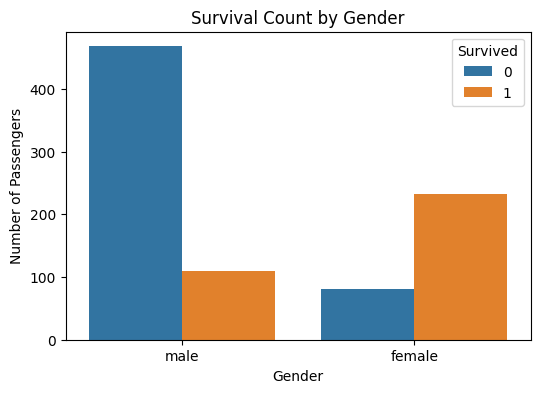

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("titanic dataset.csv.zip")

# Prepare data used for the graph
gender_survival = df.groupby(['Sex','Survived']).size().reset_index(name='Count')

# Show data in organized format
print("\nData used for plotting the graph:\n")
print(gender_survival.to_string(index=False))

# Plot graph
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df)

plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()


Data for Passenger Class vs Survival:

 Pclass  Survived  Count
   1        0       80  
   1        1      136  
   2        0       97  
   2        1       87  
   3        0      372  
   3        1      119  


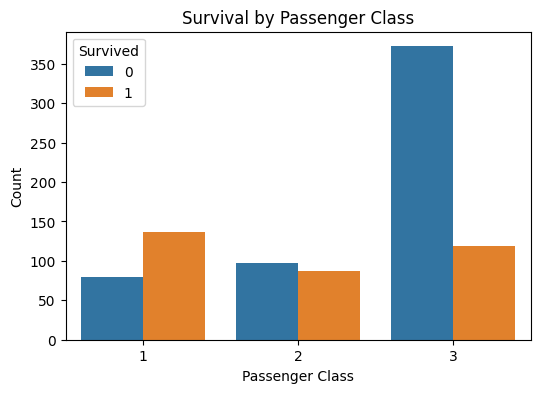

In [ ]:
# Data used for the graph
pclass_survival = df.groupby(['Pclass','Survived']).size().reset_index(name='Count')

print("\nData for Passenger Class vs Survival:\n")
print(pclass_survival.to_string(index=False))

# Plot graph
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=df)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()


Data for Age Distribution:

  Age  Frequency
 0.42      1    
 0.67      1    
 0.75      2    
 0.83      2    
 0.92      1    
 1.00      7    
 2.00     10    
 3.00      6    
 4.00     10    
 5.00      4    
 6.00      3    
 7.00      3    
 8.00      4    
 9.00      8    
10.00      2    
11.00      4    
12.00      1    
13.00      2    
14.00      6    
14.50      1    


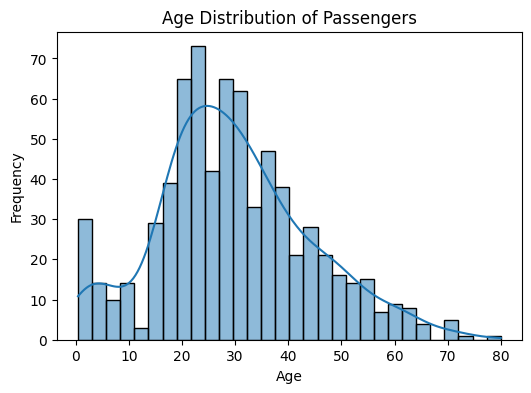

In [ ]:
# Create age frequency table
age_data = df['Age'].value_counts().sort_index().reset_index()
age_data.columns = ['Age','Frequency']

print("\nData for Age Distribution:\n")
print(age_data.head(20).to_string(index=False))

# Plot graph
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=30, kde=True)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()